In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data


In [2]:
df=load_raw_data()
df.head(10)


,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K
5,2025-06-01,52,Male,Oceania,Customer Service,Business Analyst,Onsite,61,Burnout,Medium,4,Back Pain; Shoulder Pain,3,$60K-80K
6,2025-06-01,50,Female,Asia,Manufacturing,IT Support,Onsite,62,NaN,Medium,4,Back Pain; Shoulder Pain; Wrist Pain,2,$80K-100K
7,2025-06-01,63,Non-binary,Europe,Professional Services,Technical Writer,Onsite,55,Anxiety,High,3,NaN,2,$100K-120K
8,2025-06-01,30,Female,South America,Technology,Software Engineer,Remote,47,Anxiety,Medium,2,Neck Pain,4,$60K-80K
9,2025-06-01,37,Female,Asia,Finance,HR Manager,Onsite,55,Burnout,Medium,5,Back Pain,1,$60K-80K


In [3]:
df_clean=get_da_data(df)
df_clean.head(10)

,Age,Gender,Region,Industry,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Social_Isolation_Score,Salary_Range,has_Back Pain,has_Eye Strain,has_Neck Pain,has_Shoulder Pain,has_Wrist Pain,Physical_Issues_Count,Salary_Midpoint,Job_Role_Grouped
0,27,Female,Asia,Professional Services,Onsite,64,Stress Disorder,High,3,2,$40K-60K,0,0,1,1,0,2,50000,Data Analyst
1,37,Female,Asia,Professional Services,Onsite,37,Stress Disorder,High,4,2,$80K-100K,1,0,0,0,0,1,90000,Data Analyst
2,32,Female,Africa,Education,Onsite,36,ADHD,High,3,2,$80K-100K,0,1,0,1,0,2,90000,Other
3,40,Female,Europe,Education,Onsite,63,ADHD,Medium,1,2,$60K-80K,0,1,0,1,0,2,70000,Data Analyst
4,30,Male,South America,Manufacturing,Hybrid,65,None,Medium,5,4,$60K-80K,0,0,0,0,0,0,70000,DevOps Engineer
5,52,Male,Oceania,Customer Service,Onsite,61,Burnout,Medium,4,3,$60K-80K,1,0,0,1,0,2,70000,Other
6,50,Female,Asia,Manufacturing,Onsite,62,None,Medium,4,2,$80K-100K,1,0,0,1,1,3,90000,IT Support
7,63,Non-binary,Europe,Professional Services,Onsite,55,Anxiety,High,3,2,$100K-120K,0,0,0,0,0,0,110000,Other
8,30,Female,South America,Technology,Remote,47,Anxiety,Medium,2,4,$60K-80K,0,0,1,0,0,1,70000,Other
9,37,Female,Asia,Finance,Onsite,55,Burnout,Medium,5,1,$60K-80K,1,0,0,0,0,1,70000,HR Manager


In [4]:
df_clean.info()
df_clean.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      3157 non-null   int64   
 1   Gender                   3157 non-null   category
 2   Region                   3157 non-null   category
 3   Industry                 3157 non-null   category
 4   Work_Arrangement         3157 non-null   category
 5   Hours_Per_Week           3157 non-null   int64   
 6   Mental_Health_Status     3157 non-null   category
 7   Burnout_Level            3157 non-null   category
 8   Work_Life_Balance_Score  3157 non-null   int64   
 9   Social_Isolation_Score   3157 non-null   int64   
 10  Salary_Range             3157 non-null   str     
 11  has_Back Pain            3157 non-null   int64   
 12  has_Eye Strain           3157 non-null   int64   
 13  has_Neck Pain            3157 non-null   int64   
 14  has_Shoulder Pain  

,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score,has_Back Pain,has_Eye Strain,has_Neck Pain,has_Shoulder Pain,has_Wrist Pain,Physical_Issues_Count,Salary_Midpoint
count,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000
mean,43.732024,49.904973,2.996516,2.704783,0.495090,0.508077,0.252772,0.477352,0.147925,1.881216,82682.926829
std,12.661095,8.897699,1.163307,1.188887,0.500055,0.500014,0.434670,0.499566,0.355082,1.054662,22319.375046
min,22.000000,35.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50000.000000
25%,33.000000,42.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70000.000000
50%,44.000000,50.000000,3.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,90000.000000
75%,55.000000,57.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,90000.000000
max,65.000000,65.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,130000.000000


In [5]:
df_clean2=get_ds_data(df)
df_clean2.head(10)

,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score,has_Back Pain,has_Eye Strain,has_Neck Pain,has_Shoulder Pain,has_Wrist Pain,Salary_Midpoint,...,Job_Role_Project Manager,Job_Role_Research Scientist,Job_Role_Social Media Manager,Work_Arrangement_Onsite,Work_Arrangement_Remote,Mental_Health_Status_Anxiety,Mental_Health_Status_Depression,Mental_Health_Status_None,Mental_Health_Status_PTSD,Mental_Health_Status_Stress Disorder
0,27,64,3,2,0,0,1,1,0,50000,...,0,0,0,1,0,0,0,0,0,1
1,37,37,4,2,1,0,0,0,0,90000,...,0,0,0,1,0,0,0,0,0,1
2,32,36,3,2,0,1,0,1,0,90000,...,0,0,0,1,0,0,0,0,0,0
3,40,63,1,2,0,1,0,1,0,70000,...,0,0,0,1,0,0,0,0,0,0
4,30,65,5,4,0,0,0,0,0,70000,...,0,0,0,0,0,0,0,1,0,0
5,52,61,4,3,1,0,0,1,0,70000,...,0,0,0,1,0,0,0,0,0,0
6,50,62,4,2,1,0,0,1,1,90000,...,0,0,0,1,0,0,0,1,0,0
7,63,55,3,2,0,0,0,0,0,110000,...,0,0,0,1,0,1,0,0,0,0
8,30,47,2,4,0,0,1,0,0,70000,...,0,0,0,0,1,1,0,0,0,0
9,37,55,5,1,1,0,0,0,0,70000,...,0,0,0,1,0,0,0,0,0,0


In [6]:
df_clean2.info()
df_clean2.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 43 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   Age                                   3157 non-null   int64
 1   Hours_Per_Week                        3157 non-null   int64
 2   Work_Life_Balance_Score               3157 non-null   int64
 3   Social_Isolation_Score                3157 non-null   int64
 4   has_Back Pain                         3157 non-null   int64
 5   has_Eye Strain                        3157 non-null   int64
 6   has_Neck Pain                         3157 non-null   int64
 7   has_Shoulder Pain                     3157 non-null   int64
 8   has_Wrist Pain                        3157 non-null   int64
 9   Salary_Midpoint                       3157 non-null   int64
 10  Gender_Male                           3157 non-null   int64
 11  Gender_Non-binary                     3157 non-null   

,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score,has_Back Pain,has_Eye Strain,has_Neck Pain,has_Shoulder Pain,has_Wrist Pain,Salary_Midpoint,...,Job_Role_Project Manager,Job_Role_Research Scientist,Job_Role_Social Media Manager,Work_Arrangement_Onsite,Work_Arrangement_Remote,Mental_Health_Status_Anxiety,Mental_Health_Status_Depression,Mental_Health_Status_None,Mental_Health_Status_PTSD,Mental_Health_Status_Stress Disorder
count,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,...,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000
mean,43.732024,49.904973,2.996516,2.704783,0.495090,0.508077,0.252772,0.477352,0.147925,82682.926829,...,0.043079,0.047830,0.045613,0.494774,0.186253,0.124802,0.122268,0.253088,0.133988,0.119734
std,12.661095,8.897699,1.163307,1.188887,0.500055,0.500014,0.434670,0.499566,0.355082,22319.375046,...,0.203067,0.213441,0.208677,0.500052,0.389372,0.330547,0.327647,0.434850,0.340693,0.324702
min,22.000000,35.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50000.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,42.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70000.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,44.000000,50.000000,3.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,90000.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,57.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,0.000000,90000.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,65.000000,65.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,130000.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
print(df.shape)
print(df_clean.shape)
df_clean2.shape

(3157, 14)
(3157, 19)


(3157, 43)

In [8]:
#overview
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Survey_Date              3157 non-null   str  
 1   Age                      3157 non-null   int64
 2   Gender                   3157 non-null   str  
 3   Region                   3157 non-null   str  
 4   Industry                 3157 non-null   str  
 5   Job_Role                 3157 non-null   str  
 6   Work_Arrangement         3157 non-null   str  
 7   Hours_Per_Week           3157 non-null   int64
 8   Mental_Health_Status     2358 non-null   str  
 9   Burnout_Level            3157 non-null   str  
 10  Work_Life_Balance_Score  3157 non-null   int64
 11  Physical_Health_Issues   2877 non-null   str  
 12  Social_Isolation_Score   3157 non-null   int64
 13  Salary_Range             3157 non-null   str  
dtypes: int64(4), str(10)
memory usage: 345.4 KB


,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score
count,3157.000000,3157.000000,3157.000000,3157.000000
mean,43.732024,49.904973,2.996516,2.704783
std,12.661095,8.897699,1.163307,1.188887
min,22.000000,35.000000,1.000000,1.000000
25%,33.000000,42.000000,2.000000,2.000000
50%,44.000000,50.000000,3.000000,3.000000
75%,55.000000,57.000000,4.000000,4.000000
max,65.000000,65.000000,5.000000,5.000000


In [17]:
# dữ liệu thiếu
df.isnull().sum()


Survey_Date                  0
Age                          0
Gender                       0
Region                       0
Industry                     0
Job_Role                     0
Work_Arrangement             0
Hours_Per_Week               0
Mental_Health_Status       799
Burnout_Level                0
Work_Life_Balance_Score      0
Physical_Health_Issues     280
Social_Isolation_Score       0
Salary_Range                 0
dtype: int64

In [10]:
#dữ liệu ko trùng lặp
df.duplicated().sum()

np.int64(0)

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

print(f"Tổng số cột dạng chuỗi cần kiểm tra: {len(categorical_cols)}")

for col in categorical_cols:
    print(f"--- Kiểm tra cột: {col} ---")
    print(f"Số lượng giá trị duy nhất: {df[col].nunique()}")
    
    values=df[col].dropna().astype(str).unique()
    print(f"Các giá trị xuất hiện: {sorted(values)[:20]}")
    print("\n")

Tổng số cột dạng chuỗi cần kiểm tra: 10
--- Kiểm tra cột: Survey_Date ---
Số lượng giá trị duy nhất: 26
Các giá trị xuất hiện: ['2025-06-01', '2025-06-02', '2025-06-03', '2025-06-04', '2025-06-05', '2025-06-06', '2025-06-07', '2025-06-08', '2025-06-09', '2025-06-10', '2025-06-11', '2025-06-12', '2025-06-13', '2025-06-14', '2025-06-15', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-19', '2025-06-20']


--- Kiểm tra cột: Gender ---
Số lượng giá trị duy nhất: 4
Các giá trị xuất hiện: ['Female', 'Male', 'Non-binary', 'Prefer not to say']


--- Kiểm tra cột: Region ---
Số lượng giá trị duy nhất: 6
Các giá trị xuất hiện: ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']


--- Kiểm tra cột: Industry ---
Số lượng giá trị duy nhất: 9
Các giá trị xuất hiện: ['Customer Service', 'Education', 'Finance', 'Healthcare', 'Manufacturing', 'Marketing', 'Professional Services', 'Retail', 'Technology']


--- Kiểm tra cột: Job_Role ---
Số lượng giá trị duy nhất: 24
Các giá trị 

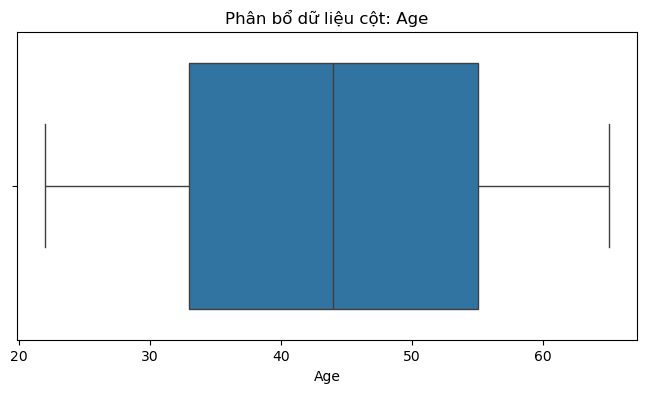

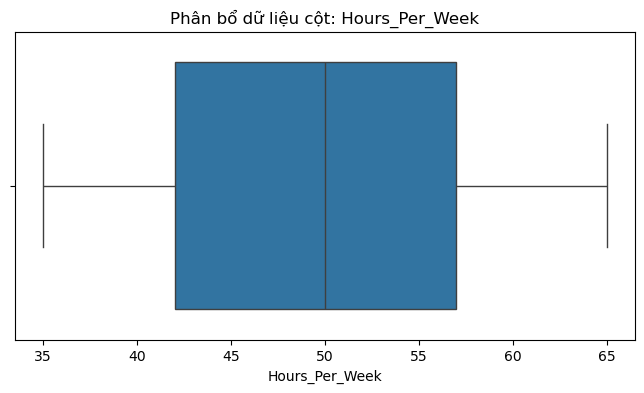

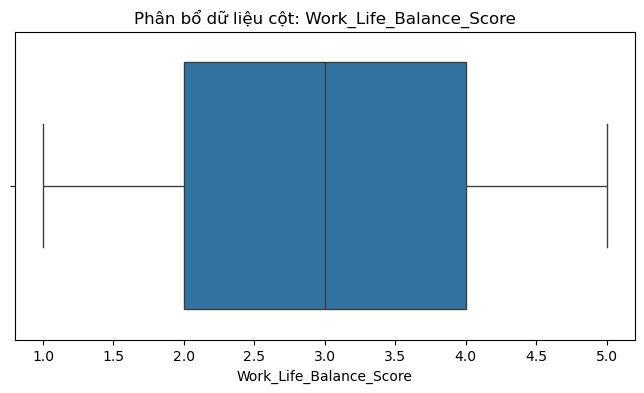

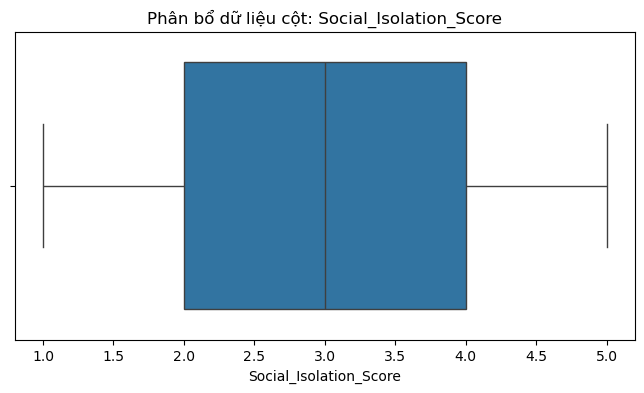

In [12]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Phân bổ dữ liệu cột: {col}")
    plt.show()

In [20]:
# Tạo bảng chéo giữa Mental_Health_Status và Burnout_Level
logic_check = pd.crosstab(df_clean['Mental_Health_Status'], df_clean['Burnout_Level'])

print("Bảng kiểm tra logic:")
print(logic_check)

Bảng kiểm tra logic:
Burnout_Level         Low  Medium  High
Mental_Health_Status                   
ADHD                  109     157   119
Anxiety                92     166   136
Burnout                95     178   119
Depression             88     174   124
None                  180     340   279
PTSD                  106     177   140
Stress Disorder        75     174   129
